In [1]:
import torch
import einops
import random

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field, replace, fields, is_dataclass
from omegaconf import OmegaConf
from torch.utils.data import DataLoader
from scipy.special import erf

from utils.config import *
from utils.einmask import EinMask
from utils.dataset import NinoData
from utils.loss_fn import f_gaussian_crps

from pathlib import Path

In [2]:
job_id = "2539299"
config_path = Path(f'runs/{job_id}/config.yaml')

config = OmegaConf.load(config_path)
config = MTMConfig.from_omegaconf(config)

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [13]:
class Evaluation:
    def __init__(self, cfg: MTMConfig, task: str = 'frcst'):
        self._cfg = cfg
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

        self.task = task

        self.create_paths()
        self.generator = self.create_seed()
        self.val_dataset, self.val_dl = self.create_dataset()
        self.model = self.create_model()

    # SETUP
    def create_paths(self):
        self.model_dir = Path(self.cfg.model_dir) / self.cfg.job_name
        self.ckpt_path = self.model_dir / 'ckpt.pth'
        self.best_path = self.model_dir / 'best.pth'
        self.cfg_path = self.model_dir / 'config.yaml'

    def create_model(self):
        model = EinMask(self.model_cfg, self.world)
        ckpt = torch.load(self.ckpt_path, map_location='cpu')
        state = {k.removeprefix('module.'): v for k, v in ckpt['model_state'].items()}
        model.load_state_dict(state)
        return model.to(self.device)

    def create_dataset(self):
        val_dataset = getattr(self, f'{self.data_cfg.eval_data.lower()}_data')()
        
        self._lsm = einops.repeat(
            torch.logical_not(val_dataset.land_sea_mask.to(dtype=torch.bool)),
            f'1 (h hh) (w ww) -> {self.world.field_pattern}',
            **self.world.token_sizes, **self.world.patch_sizes
        ).to(self.device)

        val_dl = DataLoader(val_dataset, shuffle= False, batch_size= self.world.batch_size, drop_last= True) # 1 batch = 4 years
        return val_dataset, val_dl

    def create_seed(self):
        if not exists(self.cfg.seed):
            seed = int.from_bytes(random.randbytes(4), byteorder='little')
            self.cfg.seed = seed
            dist.broadcast_object_list([seed])
        np.random.seed(self.cfg.seed)
        random.seed(self.cfg.seed)
        torch.manual_seed(self.cfg.seed)
        torch.cuda.manual_seed(self.cfg.seed)
        return torch.Generator(device=self.device).manual_seed(self.cfg.seed)

    # DATA
    def lens_data(self) -> NinoData:
        if not hasattr(self, "_lens_data"):
            lens_config = self.data_cfg
            lens_config = replace(lens_config, 
                                  time_slice = {"start": "1850", "stop": "2000", "step": None},
                                  stats = default(self.data_cfg.stats, LENS_STATS)
                                  )
            self._lens_data = MultifileNinoDataset(self.cfg.lens_path, lens_config, self.rank, self.world_size)
        return self._lens_data       

    def godas_data(self) -> NinoData:
        if not hasattr(self, "_godas_data"):
            godas_config = self.data_cfg
            godas_config = replace(godas_config, 
                                   time_slice = {"start": "1980", "stop": "2020", "step": None},
                                   stats = default(self.data_cfg.stats, GODAS_STATS)
                                   )
            self._godas_data = NinoData(self.cfg.godas_path, godas_config)
        return self._godas_data

    def picontrol_data(self) -> NinoData:
        if not hasattr(self, "_picontrol_data"):
            picontrol_config = self.data_cfg
            picontrol_config = replace(picontrol_config, 
                                       time_slice = {"start": "1900", "stop": "2000", "step": None},
                                       stats = default(self.data_cfg.stats, PICONTROL_STATS))
            self._picontrol_data = NinoData(self.cfg.picontrol_path, picontrol_config)
        return self._picontrol_data

    def oras5_data(self) -> NinoData:
        if not hasattr(self, "_oras5_data"):
            oras5_config = self.data_cfg
            oras5_config = replace(oras5_config, time_slice = {"start": "1980", "stop": "2020", "step": None})
            self._oras5_data = NinoData(self.cfg.oras5_path, oras5_config)
        return self._oras5_data

    # CONFIG
    @property
    def cfg(self) -> TrainerConfig:
        return self._cfg.trainer
    
    @property
    def data_cfg(self) -> DatasetConfig:
        return self._cfg.data

    @property
    def model_cfg(self) -> NetworkConfig:
        return self._cfg.model
    
    @property
    def world(self) -> WorldConfig:
        return self._cfg.world
    
    @property
    def objective(self) -> ObjectiveConfig:
        return self._cfg.objective
    
    # MASKING
    def sample_normal_rates_(self, mean: float, std: float, a: float = 0., b: float = 1.):
        return torch.nn.init.trunc_normal_(
            torch.empty((1,), device = self.device), 
            mean = mean, std = std, a = a, b = b, generator = self.generator
            ).mul(self.world.num_tokens).long()

    def sample_weighted_reservoir(self, num_samples: int):
        P = torch.rand((num_samples, self.world.num_tokens), device=self.device, generator=self.generator).log()
        for dim, alpha in self.objective.event_cfg.items():
            if not (exists(alpha) and dim in self.world.layout): continue
            U = torch.rand((num_samples, self.world.token_sizes[dim]), device=self.device, generator=self.generator)
            U = einops.repeat(U, f'b {dim} -> b ({self.world.token_pattern})', **self.world.token_sizes)
            P += U.log().div(alpha)
        return P
    
    def sample_block_noise(self, K: int, num_samples: int):
        d = torch.arange(1, K + 1, device = self.device)
        d = d[K % d == 0]
        idx = torch.multinomial(1 / d, 1, generator= self.generator)
        KK = d[idx]
        U = torch.rand((num_samples, K // KK), device= self.device, generator= self.generator)
        U = einops.repeat(U, f'... k -> ... (k kk)', kk = KK, k = K // KK)
        return U
    
    def sample_weighted_reservoir_blocks(self, num_samples: int):
        P = torch.rand((num_samples, self.world.num_tokens), device=self.device, generator=self.generator).log()
        for dim, alpha in self.objective.event_cfg.items():
            if not (exists(alpha) and dim in self.world.layout): continue
            U = self.sample_block_noise(self.world.token_sizes[dim], num_samples)
            U = einops.repeat(U, f'b {dim} -> b ({self.world.token_pattern})', **self.world.token_sizes)
            P += U.log().div(alpha)
        return P
    
    def sample_masks(self) -> torch.BoolTensor:
        K_src = self.sample_normal_rates_(**self.objective.rate_cfg)
        src_weights = self.sample_weighted_reservoir(self.world.batch_size)
        src_reservoir = src_weights.argsort(descending=True)
        src = src_reservoir.argsort(descending=False).lt(K_src)
        return src

    @property
    def frcst_prefix(self) -> torch.BoolTensor:
        prefix = torch.zeros((self.world.token_sizes["t"],), device = self.device, dtype = torch.bool)
        prefix[:self.world.tau] = True
        return einops.repeat(prefix, f't -> b ({self.world.token_pattern})', **self.world.token_sizes, b = self.world.batch_size)

    @property
    def intervention_prefix(self) -> torch.BoolTensor:
        indices = [self.data_cfg.variables.index(var) for var in self.data_cfg.eval_variables]
        prefix = torch.zeros((self.world.token_sizes["v"],), device = self.device, dtype = torch.bool)
        prefix[indices] = True
        return einops.repeat(prefix, f'v -> b ({self.world.token_pattern})', **self.world.token_sizes, b = self.world.batch_size)

    def make_visible(self) -> torch.BoolTensor:
        if self.task == 'frcst':
            return self.frcst_prefix
        elif self.task == 'frcst_intervention':
            return self.frcst_prefix & self.intervention_prefix
        elif self.task == 'frcst_zeros':
            return self.frcst_prefix
        elif self.task == 'masked':
            return self.sample_masks()
        else:
            raise NotImplementedError
    
    # FORWARD
    def to_xarray_eval(
            self, 
            batch_idx: int, 
            obs: torch.FloatTensor, 
            mu: torch.FloatTensor, 
            sigma: torch.FloatTensor, 
            visible: torch.BoolTensor
            ) -> xr.Dataset:
        
        meta = self.val_dataset.dataset
        batch_slice = slice(batch_idx * obs.shape[0], (batch_idx + 1) * obs.shape[0])

        vis_field = einops.repeat(
            visible,
            f'... ({self.world.token_pattern}) -> ... {self.world.field_pattern}',
            **self.world.token_sizes, **self.world.patch_sizes
        )

        arrays = []
        for v, var in enumerate(self.data_cfg.variables):
            if var not in self.data_cfg.eval_variables:
                continue
            std = self.val_dataset._stds.sel(variable=var).values.astype(np.float32)
            arrays.append(xr.Dataset(
                {
                    f'{var}_obs':        (['time', 'step', 'lat', 'lon'], obs[:, v].numpy() * std),
                    f'{var}_pred_mu':    (['time', 'step', 'lat', 'lon'], mu[:, v].numpy() * std),
                    f'{var}_pred_sigma': (['time', 'step', 'lat', 'lon'], sigma[:, v].numpy() * std),
                    f'{var}_visible':    (['time', 'step', 'lat', 'lon'], vis_field[:, v].numpy()),
                },
                coords={
                    'time': meta.time[batch_slice],
                    'step': np.arange(self.data_cfg.sequence_length),
                    'lat':  meta.lat,
                    'lon':  meta.lon,
                }
            ))
        
        return xr.merge(arrays, compat='no_conflicts')

    def run(self) -> xr.Dataset:
        results = []
        self.model.eval()

        with torch.no_grad():
            for batch_idx, batch in enumerate(self.val_dl):
                batch = batch.to(self.device)
                visible = self.make_visible().to(self.device)

                if self.task == 'frcst_zeros':
                    zeros = einops.repeat(
                        self.intervention_prefix,
                        f'... ({self.world.token_pattern}) -> ... {self.world.field_pattern}',
                        **self.world.token_sizes, **self.world.patch_sizes
                    )
                    batch = batch * zeros

                mu, sigma = self.model(batch, visible).mul(self._lsm) # times lsm zeros all land pixels
                sigma = torch.nn.functional.softplus(sigma)
                results.append(self.to_xarray_eval(
                    batch_idx, batch.cpu(), mu.cpu(), sigma.cpu(), visible.cpu()
                ))

        ds = xr.concat(results, dim='time', data_vars= 'all')

        ds['lsm'] = xr.DataArray(
            data = np.bool(self.val_dataset.land_sea_mask[0]),
            coords = {'lat': self.val_dataset.dataset.lat, 
                    'lon': self.val_dataset.dataset.lon}
        )
        

        if self.cfg.save_eval:
            self.write_to_disk(ds)
        return ds
    
    def write_to_disk(self, data: xr.Dataset):
        path = self.model_dir / f"{self.data_cfg.eval_data}_eval_{self.task}.zarr"
        data.to_zarr(path, mode = "w")

    

In [14]:
# EVAL
def get_nino4(da: xr.DataArray):
    return da.sel(lon=slice(160, 210), lat=slice(-5, 5)).mean(dim=['lon', 'lat'])

def get_nino34(da: xr.DataArray):
    return da.sel(lon=slice(190, 240), lat=slice(-5, 5)).mean(dim=['lon', 'lat'])

def xr_pcc(pred: xr.DataArray, obs: xr.DataArray, dim: tuple[str]):
    num = (pred * obs).sum(dim)
    denom = np.sqrt((pred**2).sum(dim)) * np.sqrt((obs**2).sum(dim))
    return num / denom

def xr_rmse(pred: xr.DataArray, obs: xr.DataArray, dim: tuple[str]):
    return np.sqrt(((pred - obs) ** 2).mean(dim))

def xr_spread_skill_mve(mu: xr.DataArray, sigma: xr.DataArray, obs: xr.DataArray, dim: tuple[str]):
    var = (sigma ** 2).mean(dim)
    mse = ((obs - mu) ** 2).mean(dim)
    return np.sqrt(var / mse)

def xr_rmse_ss(pred: xr.DataArray, obs: xr.DataArray, dim: tuple[str]):
    return 1 - np.sqrt(((pred - obs) ** 2).mean(dim) / (obs ** 2).mean(dim)) 

def xr_activ(pred: xr.DataArray, obs: xr.DataArray, dim: tuple[str]):
    a_p = (pred ** 2).mean(dim)
    a_o = (obs ** 2).mean(dim)
    return np.sqrt(a_p / a_o)

In [15]:
def intervention_experiment(config, vars: list, task: str = 'frcst_intervention'):
    
    eval = Evaluation(config, task = task)
    ms = []

    for var in vars:
        eval.data_cfg.eval_variables = var
        ds = eval.run()
        
        v = 'temp_ocn_0a'
        valid = ~ds[f'{v}_visible'] & ~ds['lsm']

        mu = ds[f'{v}_pred_mu'].where(valid)
        sigma = ds[f'{v}_pred_sigma'].where(valid)
        obs = ds[f'{v}_obs'].where(valid)

        mu_nino, sigma_nino, obs_nino = [get_nino34(a) for a in [mu, sigma, obs]]
        ms.append({
            'pcc_nino': xr_pcc(mu_nino, obs_nino, ['time']),
            'rmse_nino': xr_rmse(mu_nino, obs_nino, ['time']),
            'rmse_ss_nino': xr_rmse_ss(mu_nino, obs_nino, ['time']),
            'ssr_nino': xr_spread_skill_mve(mu_nino, sigma_nino, obs_nino, ['time']),
            'activ_nino': xr_activ(mu, obs, ['lat', 'lon']).mean('time'),
            f'pcc_{v}': xr_pcc(mu, obs, ['lat', 'lon']).mean('time'),
            f'rmse_{v}': xr_rmse(mu, obs, ['lat', 'lon']).mean('time'),
            f'rmse_ss_{v}': xr_rmse_ss(mu, obs, ['lat', 'lon']).mean('time'),
            f'ssr_{v}': xr_spread_skill_mve(mu, sigma, obs, ['lat', 'lon']).mean('time'),
            f'activ_{v}': xr_activ(mu, obs, ['lat', 'lon']).mean('time'),
        })
    return ms

In [7]:

config.world.batch_size = 48
config.trainer.save_eval = False
config.data.eval_data = 'picontrol'

vars = [['temp_ocn_0a'], ['temp_ocn_0a', 'tauxa'], ['temp_ocn_0a', 'temp_ocn_14a'], ['temp_ocn_0a', 'temp_ocn_14a', 'tauxa']]

experiment = intervention_experiment(config, vars)



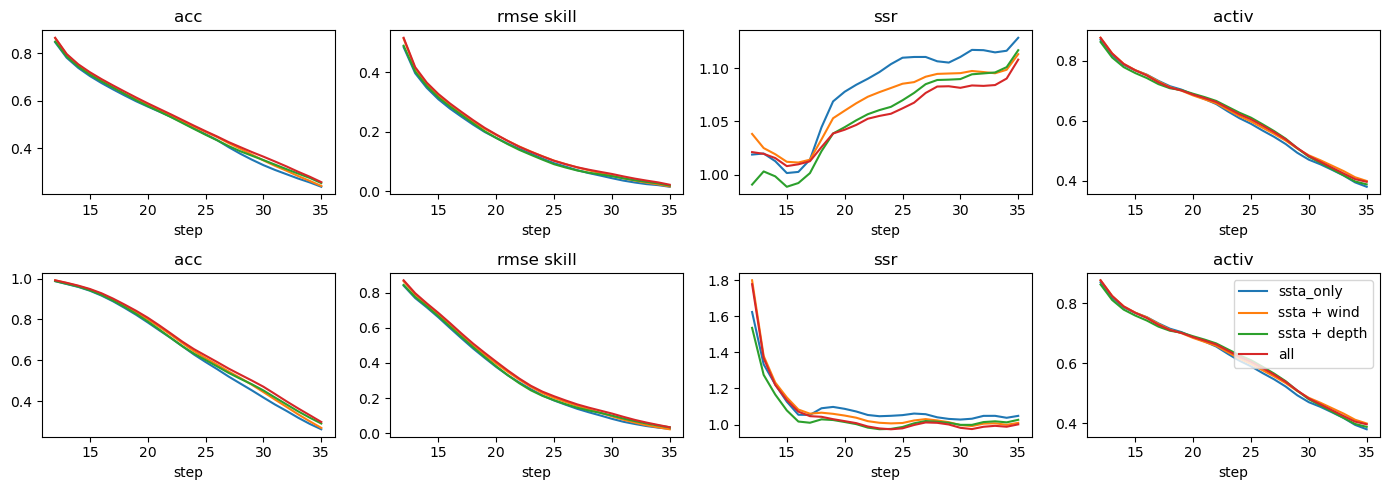

In [10]:
plt.figure(figsize=(14, 5))
for ms in experiment:
    v = 'temp_ocn_0a'
    plt.subplot(2,4,1)
    ms[f'pcc_{v}'].plot()
    plt.title(f'acc')
    plt.subplot(2,4,2)
    (ms[f'rmse_ss_{v}']).plot()
    plt.title(f'rmse skill')
    plt.subplot(2,4,3)
    ms[f'ssr_{v}'].plot()
    plt.title(f'ssr')
    plt.subplot(2,4,4)
    ms[f'activ_{v}'].plot()
    plt.title(f'activ')

    v = 'nino'
    plt.subplot(2,4,5)
    ms[f'pcc_{v}'].plot()
    plt.title(f'acc')
    plt.subplot(2,4,6)
    (ms[f'rmse_ss_{v}']).plot()
    plt.title(f'rmse skill')
    plt.subplot(2,4,7)
    ms[f'ssr_{v}'].plot()
    plt.title(f'ssr')
    plt.subplot(2,4,8)
    ms[f'activ_{v}'].plot()
    plt.title(f'activ')
plt.legend(['ssta_only', 'ssta + wind', 'ssta + depth', 'all'])
plt.tight_layout()

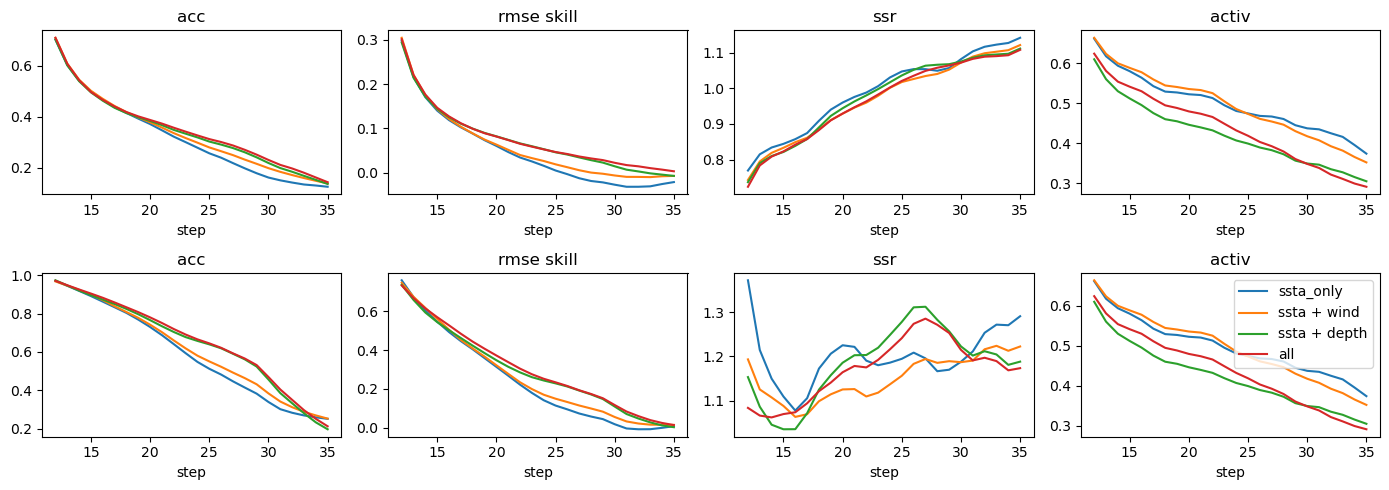

In [12]:

config.world.batch_size = 48
config.trainer.save_eval = False
config.data.eval_data = 'godas'

vars = [['temp_ocn_0a'], ['temp_ocn_0a', 'tauxa'], ['temp_ocn_0a', 'temp_ocn_14a'], ['temp_ocn_0a', 'temp_ocn_14a', 'tauxa']]

experiment = intervention_experiment(config, vars)

plt.figure(figsize=(14, 5))
for ms in experiment:
    v = 'temp_ocn_0a'
    plt.subplot(2,4,1)
    ms[f'pcc_{v}'].plot()
    plt.title(f'acc')
    plt.subplot(2,4,2)
    (ms[f'rmse_ss_{v}']).plot()
    plt.title(f'rmse skill')
    plt.subplot(2,4,3)
    ms[f'ssr_{v}'].plot()
    plt.title(f'ssr')
    plt.subplot(2,4,4)
    ms[f'activ_{v}'].plot()
    plt.title(f'activ')

    v = 'nino'
    plt.subplot(2,4,5)
    ms[f'pcc_{v}'].plot()
    plt.title(f'acc')
    plt.subplot(2,4,6)
    (ms[f'rmse_ss_{v}']).plot()
    plt.title(f'rmse skill')
    plt.subplot(2,4,7)
    ms[f'ssr_{v}'].plot()
    plt.title(f'ssr')
    plt.subplot(2,4,8)
    ms[f'activ_{v}'].plot()
    plt.title(f'activ')
plt.legend(['ssta_only', 'ssta + wind', 'ssta + depth', 'all'])
plt.tight_layout()

In [ ]:

config.world.batch_size = 48
config.trainer.save_eval = False
config.data.eval_data = 'picontrol'

vars = [['temp_ocn_0a'], ['temp_ocn_0a', 'tauxa'], ['temp_ocn_0a', 'temp_ocn_14a'], ['temp_ocn_0a', 'temp_ocn_14a', 'tauxa']]

experiment = intervention_experiment(config, vars, 'frcst_zeros')

plt.figure(figsize=(14, 5))
for ms in experiment:
    v = 'temp_ocn_0a'
    plt.subplot(2,4,1)
    ms[f'pcc_{v}'].plot()
    plt.title(f'acc')
    plt.subplot(2,4,2)
    (ms[f'rmse_ss_{v}']).plot()
    plt.title(f'rmse skill')
    plt.subplot(2,4,3)
    ms[f'ssr_{v}'].plot()
    plt.title(f'ssr')
    plt.subplot(2,4,4)
    ms[f'activ_{v}'].plot()
    plt.title(f'activ')

    v = 'nino'
    plt.subplot(2,4,5)
    ms[f'pcc_{v}'].plot()
    plt.title(f'acc')
    plt.subplot(2,4,6)
    (ms[f'rmse_ss_{v}']).plot()
    plt.title(f'rmse skill')
    plt.subplot(2,4,7)
    ms[f'ssr_{v}'].plot()
    plt.title(f'ssr')
    plt.subplot(2,4,8)
    ms[f'activ_{v}'].plot()
    plt.title(f'activ')
plt.legend(['ssta_only', 'ssta + wind', 'ssta + depth', 'all'])
plt.tight_layout()

In [19]:
config.world.batch_size = 48
config.trainer.save_eval = False
config.objective.event_cfg = {}
config.data.eval_data = 'piControl'

eval = Evaluation(config, task = 'masked')

metrics = []
rates = np.linspace(0.01, 0.99, 20)
for m in rates:
    
    eval.objective.rate_cfg = {'mean': m, 'std': 1e-6}
    
    ds = eval.run()

    valid = ~ds['temp_ocn_0a_visible'] & ~ds['lsm']

    mu = ds['temp_ocn_0a_pred_mu'].where(valid)
    sigma = ds['temp_ocn_0a_pred_sigma'].where(valid)
    obs = ds['temp_ocn_0a_obs'].where(valid)

    #mu, sigma, obs = [get_nino4(a) for a in [mu, sigma, obs]]

    ms = {
        'pcc': xr_pcc(mu, obs, ['lat', 'lon', 'step']).mean('time'),
        'rmse': xr_rmse(mu, obs, ['lat', 'lon', 'step']).mean('time'),
        'ssr': xr_spread_skill_mve(mu, sigma, obs, ['lat', 'lon', 'step']).mean('time'),
    }
    metrics.append(ms)

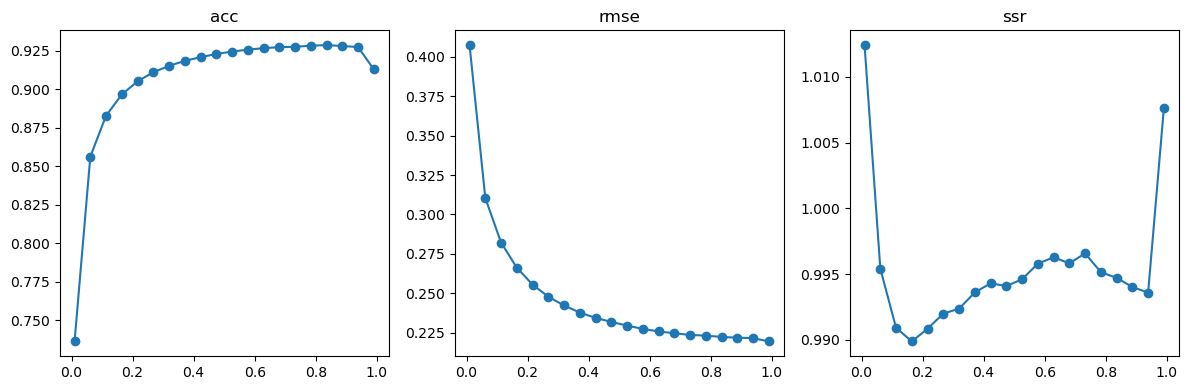

In [32]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.plot(rates, [m['pcc'] for m in metrics], 'o-')
plt.title('acc')
plt.subplot(132)
plt.plot(rates, [m['rmse'] for m in metrics], 'o-')
plt.title('rmse')
plt.subplot(133)
plt.title('ssr')
plt.plot(rates, [m['ssr'] for m in metrics], 'o-')
plt.tight_layout()